# Task 13 — Time Series Forecasting

## Project Overview

This project focuses on time series forecasting for a grocery retail business.

The objective is to analyze historical sales data and develop forecasting approaches that can help predict future sales. The project covers time series exploration, stationarity testing, decomposition, traditional statistical forecasting methods, and machine learning-based forecasting.

The main forecasting approaches considered are:

- ARIMA
- Prophet
- XGBoost with lag-based features

Time-aware validation techniques are used to avoid data leakage and provide a realistic evaluation of forecasting performance.

## Business Problem

A grocery chain operates 54 stores and needs accurate sales forecasts for inventory ordering.

The business requires forecasts for the next 16 days so that inventory can be planned according to expected demand.

Overforecasting can result in excess inventory and approximately $45K per week in wasted goods, while underforecasting can lead to empty shelves and approximately $60K per week in lost sales.

Therefore, the goal is to build reliable forecasting approaches that can support better inventory planning and reduce the cost of inaccurate forecasts.

## Learning Objectives

The main learning objectives of this task are:

1. Understand the fundamentals of time series forecasting.
2. Analyze trends and seasonality in historical sales data.
3. Test stationarity using the Augmented Dickey-Fuller (ADF) test.
4. Apply time series decomposition.
5. Understand and implement ARIMA and Prophet forecasting approaches.
6. Create lag-based features for machine learning forecasting.
7. Apply XGBoost for time series prediction.
8. Use time-aware validation techniques such as TimeSeriesSplit.
9. Compare forecasting approaches using relevant evaluation metrics.
10. Interpret forecasting results in a business context.

## Import Libraries

The following libraries are used for data manipulation, visualization, statistical analysis, forecasting, machine learning, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

The Store Sales time series dataset is loaded into a pandas DataFrame for further exploration and preprocessing.


In [2]:
df = pd.read_csv("Store Sales - Time Series Forecasting.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1187270, 6)


## Initial Data Inspection

The dataset is inspected to understand its structure, data types, available variables, and potential data quality issues before performing forecasting analysis.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

First 5 rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1.0,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1.0,BABY CARE,0.0,0.0
2,2,2013-01-01,1.0,BEAUTY,0.0,0.0
3,3,2013-01-01,1.0,BEVERAGES,0.0,0.0
4,4,2013-01-01,1.0,BOOKS,0.0,0.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187270 entries, 0 to 1187269
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1187270 non-null  int64  
 1   date         1187270 non-null  object 
 2   store_nbr    1187269 non-null  float64
 3   family       1187269 non-null  object 
 4   sales        1187269 non-null  float64
 5   onpromotion  1187269 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 54.3+ MB


In [4]:
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:


,0
id,0
date,0
store_nbr,1
family,1
sales,1
onpromotion,1



Duplicate Rows: 0


In [5]:
print("Statistical Summary:")
display(df.describe(include="all"))

Statistical Summary:


,id,date,store_nbr,family,sales,onpromotion
count,1.187270e+06,1187270,1.187269e+06,1187269,1.187269e+06,1.187269e+06
unique,NaN,668,NaN,33,NaN,NaN
top,NaN,2014-10-29,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,1782,NaN,35978,NaN,NaN
mean,5.936345e+05,NaN,2.749458e+01,NaN,2.561204e+02,2.444779e-01
std,3.427355e+05,NaN,1.558566e+01,NaN,8.383839e+02,3.663958e+00
min,0.000000e+00,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,2.968172e+05,NaN,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,5.936345e+05,NaN,2.700000e+01,NaN,2.000000e+00,0.000000e+00
75%,8.904518e+05,NaN,4.100000e+01,NaN,1.279020e+02,0.000000e+00


## Date Processing

Time series forecasting requires a properly formatted time index. The date column is converted into pandas datetime format so that observations can be sorted chronologically and analyzed over time.

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

ValueError: time data "20" doesn't match format "%Y-%m-%d", at position 667. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## Understanding the Time Series Structure

The dataset may contain sales observations for multiple stores and product families. Before modeling, the forecasting target needs to be defined at an appropriate time level.

For this project, the sales observations will be organized chronologically so that historical information is used to predict future values without using future observations during training.

In [7]:
print("Number of unique dates:", df["date"].nunique())

if "store_nbr" in df.columns:
    print("Number of stores:", df["store_nbr"].nunique())

if "family" in df.columns:
    print("Number of product families:", df["family"].nunique())

Number of unique dates: 668
Number of stores: 54
Number of product families: 33


## Daily Sales Aggregation

The original dataset contains sales observations across stores and product families.

To create a single forecasting series, sales are aggregated by date. This provides the total daily sales across the available stores and product categories.

Daily aggregation simplifies the forecasting problem while preserving the overall demand pattern required for inventory planning.

In [8]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

print("Daily sales shape:", daily_sales.shape)
display(daily_sales.head())

Daily sales shape: (668, 2)


,date,sales
0,20,0.000000
1,2013-01-01,2511.618999
2,2013-01-02,496092.417944
3,2013-01-03,361461.231124
4,2013-01-04,354459.677093


In [9]:
print("Daily Sales Summary:")
display(daily_sales["sales"].describe())

Daily Sales Summary:


,sales
count,668.000000
mean,455215.248465
std,153227.893378
min,0.000000
25%,335329.315682
50%,419253.148493
75%,540165.039278
max,997964.077948


## Daily Sales Trend

The daily sales series is plotted to identify overall trends, unusual fluctuations, and possible seasonal patterns.

Visual inspection is an important first step before applying statistical forecasting models.

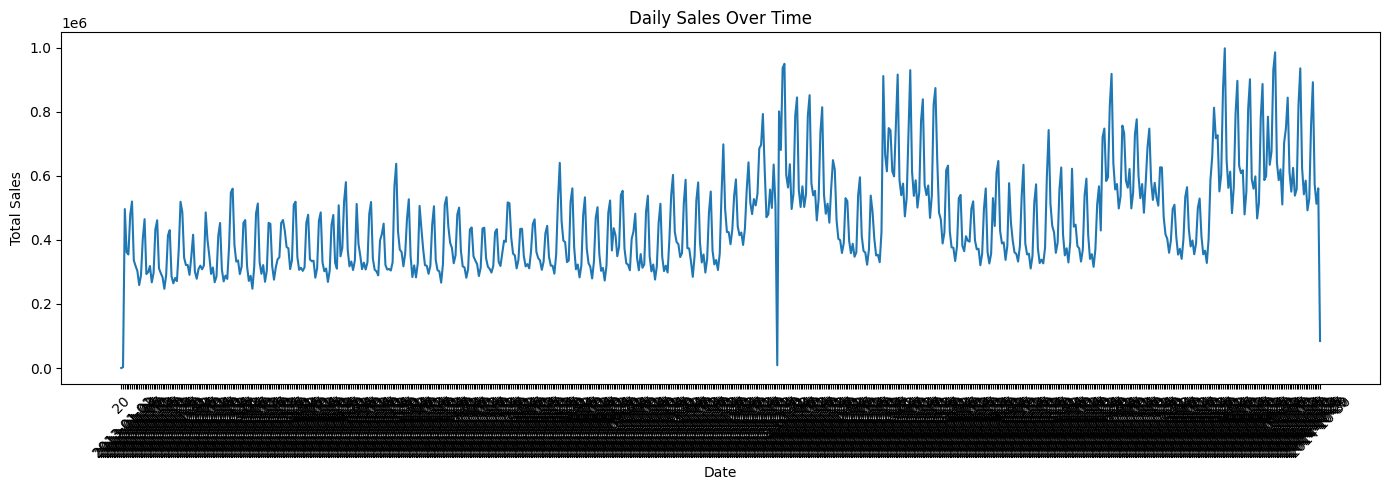

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Rolling Mean and Standard Deviation

Rolling statistics are used to examine whether the mean and variability of the time series remain relatively stable over time.

A changing rolling mean or standard deviation can indicate that the series may not be stationary.

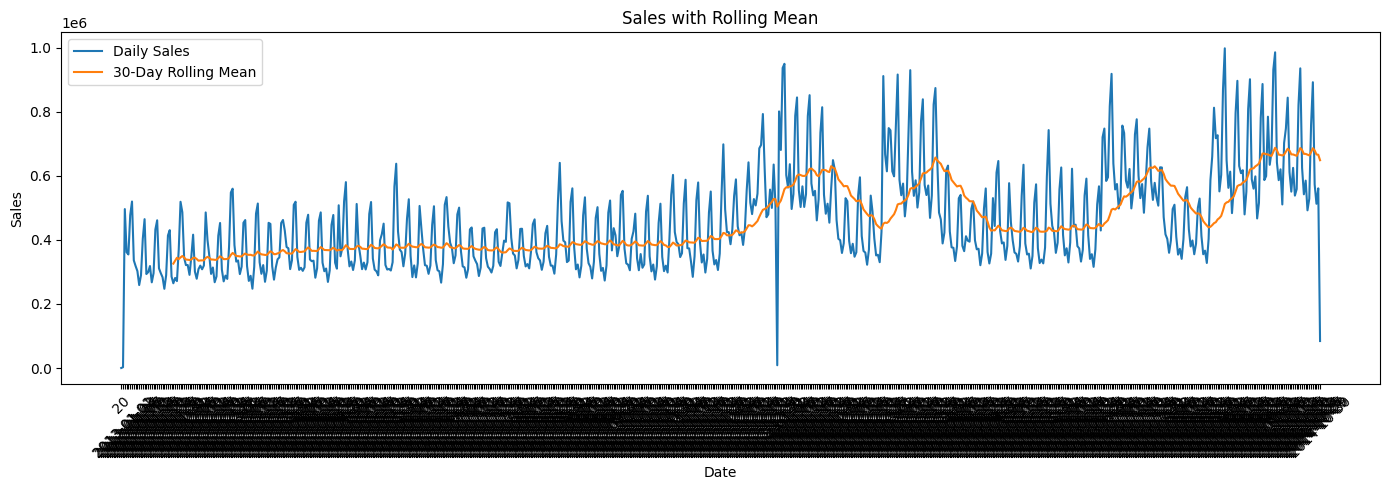

In [11]:
daily_sales["rolling_mean"] = (
    daily_sales["sales"]
    .rolling(window=30)
    .mean()
)

daily_sales["rolling_std"] = (
    daily_sales["sales"]
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean"],
    label="30-Day Rolling Mean"
)

plt.title("Sales with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Stationarity Testing — Augmented Dickey-Fuller Test

Stationarity is an important concept in time series forecasting.

A stationary time series has statistical properties such as mean and variance that remain relatively stable over time.

The Augmented Dickey-Fuller (ADF) test is used to determine whether the series contains a unit root.

### Hypotheses

- H0: The time series is non-stationary.
- H1: The time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected and the series is considered stationary at the selected significance level.

In [12]:
sales_series = daily_sales["sales"].dropna()

adf_result = adfuller(sales_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The series is likely stationary.")
else:
    print("Conclusion: The series is likely non-stationary.")

ADF Statistic: -2.7170697632026215
p-value: 0.07113074578619503
Conclusion: The series is likely non-stationary.


## Time Series Decomposition

Time series decomposition separates a series into major components:

- Trend
- Seasonality
- Residual

This helps identify long-term movement and repeating patterns in sales.

A weekly seasonal period is initially considered because grocery sales can exhibit weekly purchasing patterns.

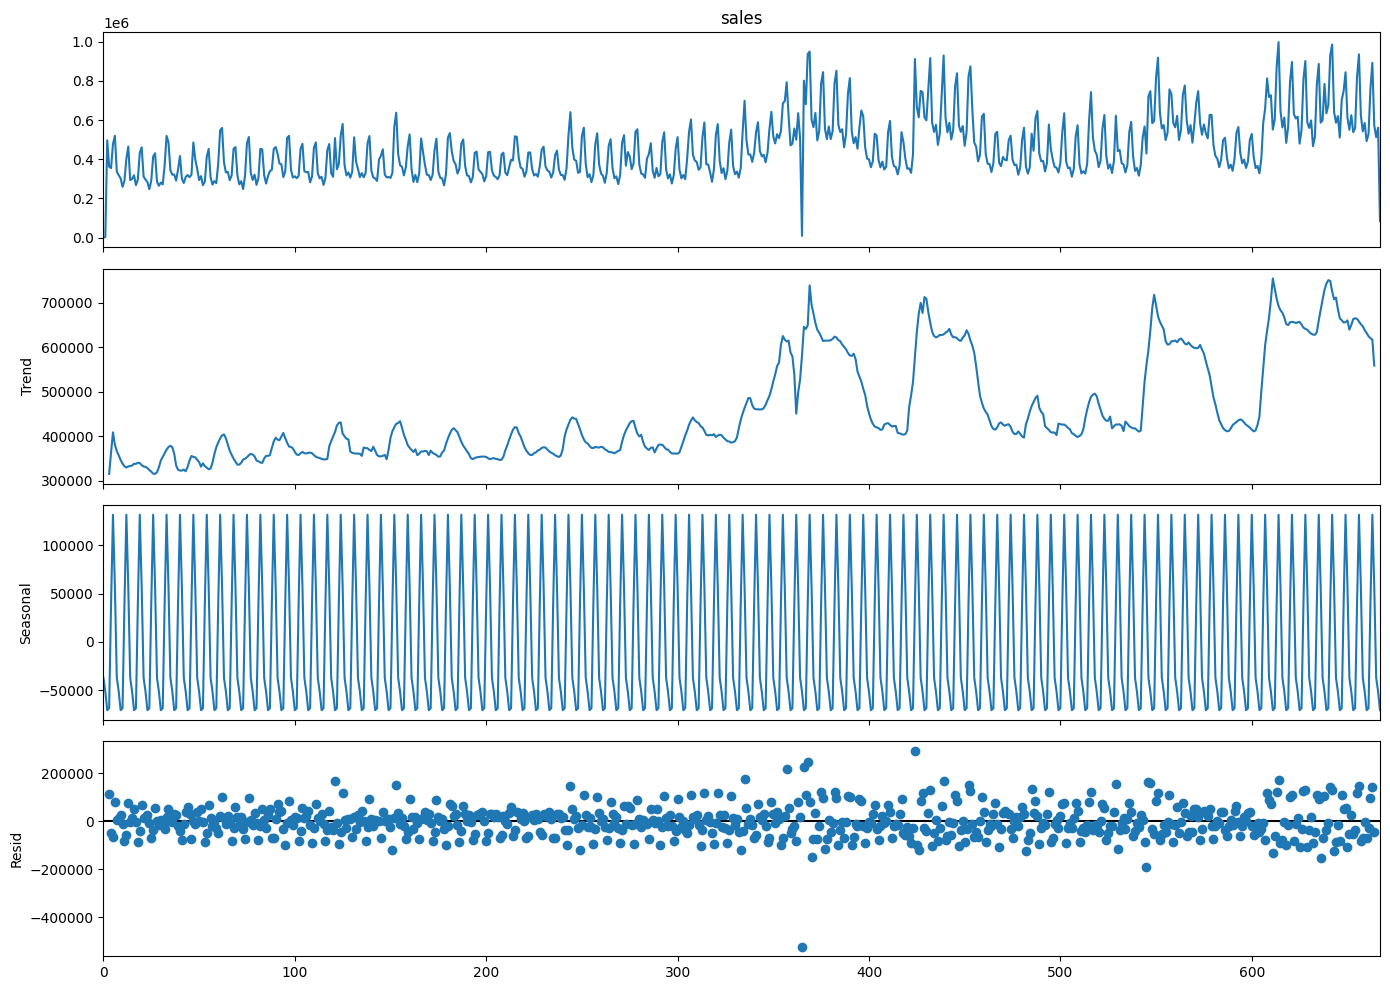

In [13]:
decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

## Prepare Modeling Series

The date and sales columns are retained for forecasting. The observations are kept in chronological order because future observations must never be used to train a model for earlier periods.

In [14]:
ts = daily_sales[["date", "sales"]].copy()

ts = ts.sort_values("date").reset_index(drop=True)

print("Time series observations:", len(ts))
display(ts.head())

Time series observations: 668


,date,sales
0,20,0.000000
1,2013-01-01,2511.618999
2,2013-01-02,496092.417944
3,2013-01-03,361461.231124
4,2013-01-04,354459.677093


## Time-Based Train/Test Split

Unlike traditional machine learning, time series data should not be randomly shuffled before splitting.

The earlier observations are used for training, while the most recent observations are reserved for testing. This better represents the real forecasting scenario where historical data is used to predict future values.

In [15]:
test_size = 16

train = ts.iloc[:-test_size].copy()
test = ts.iloc[-test_size:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training observations: 652
Testing observations: 16

Training period:
20 to 2014-10-14

Testing period:
2014-10-15 to 2014-10-30


## Baseline Forecast

A simple baseline is created using the most recent observed sales value.

The baseline provides a reference point for judging whether more advanced forecasting models provide meaningful improvement.

In [16]:
last_value = train["sales"].iloc[-1]

baseline_predictions = np.repeat(
    last_value,
    len(test)
)

baseline_mae = mean_absolute_error(
    test["sales"],
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["sales"],
        baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 127092.75688968752
Baseline RMSE: 196385.41038078157


## Date Cleaning and Data Validation

The date column is converted into a datetime format before performing time series analysis.

During inspection, an invalid value was identified in the date column. Invalid dates are converted to missing values and handled through appropriate data cleaning rather than being interpreted as valid observations.

The dataset is then sorted chronologically to maintain the correct temporal order.

In [17]:
# Convert date values to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check invalid/missing dates created during conversion
print("Missing/Invalid dates:", df["date"].isna().sum())

# Display rows with invalid dates
display(df[df["date"].isna()])

Missing/Invalid dates: 1


,id,date,store_nbr,family,sales,onpromotion
1187269,1187269,NaT,NaN,NaN,NaN,NaN


In [18]:
# Remove rows with invalid dates
df = df.dropna(subset=["date"]).copy()

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

print("Shape after date cleaning:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

Shape after date cleaning: (1187269, 6)
Date range: 2013-01-01 00:00:00 to 2014-10-30 00:00:00


## Missing Value Handling

The dataset contains one missing observation in several columns.

Since the affected row does not contain a valid date and cannot be reliably placed in the time series, it is removed during the cleaning stage.

For valid observations, numeric sales-related missing values are handled using appropriate numeric replacements, while categorical fields are filled using their most frequent value where required.

In [19]:
print("Missing values after date cleaning:")
display(df.isnull().sum())

Missing values after date cleaning:


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [20]:
# Fill numeric columns using median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns using mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after preprocessing:")
display(df.isnull().sum())

Missing values after preprocessing:


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


## Cleaned Dataset Overview

After handling invalid dates and missing values, the dataset is inspected again to verify that the data is ready for time series analysis.

In [21]:
print("Final dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nUnique stores:", df["store_nbr"].nunique())
print("Unique product families:", df["family"].nunique())

Final dataset shape: (1187269, 6)

Data types:


,0
id,int64
date,datetime64[ns]
store_nbr,float64
family,object
sales,float64
onpromotion,float64



Date range:
2013-01-01 00:00:00 to 2014-10-30 00:00:00

Unique stores: 54
Unique product families: 33


## Daily Sales Aggregation

The dataset contains sales observations for multiple stores and product families.

For the initial forecasting analysis, sales are aggregated across stores and product families for each date. This produces one overall daily sales time series representing total grocery sales.

This aggregation provides a clear business-level demand signal for inventory planning.

In [22]:
daily_sales = (
    df.groupby("date", as_index=False)["sales"]
    .sum()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Daily sales shape:", daily_sales.shape)
display(daily_sales.head())

Daily sales shape: (667, 2)


,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [23]:
print("Daily sales summary:")
display(daily_sales["sales"].describe())

Daily sales summary:


,sales
count,667.000000
mean,455897.730097
std,152323.444475
min,2511.618999
25%,335479.238467
50%,420576.154994
75%,540173.453499
max,997964.077948


## Checking for Missing Dates

A continuous daily time series is required for reliable time series analysis.

The date range is checked for missing calendar days. If missing dates are found, they can be represented explicitly and handled according to the forecasting context.

In [24]:
full_dates = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(daily_sales["date"])

print("Expected number of dates:", len(full_dates))
print("Available dates:", len(daily_sales))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nFirst missing dates:")
    print(missing_dates[:10])
else:
    print("No missing calendar dates found.")

Expected number of dates: 668
Available dates: 667
Missing dates: 1

First missing dates:
DatetimeIndex(['2013-12-25'], dtype='datetime64[ns]', freq='D')


## Time Series Index

The date column is set as the index because time series operations such as rolling statistics, decomposition, and forecasting models work naturally with a chronological datetime index.

In [25]:
ts = daily_sales.set_index("date")["sales"].copy()

ts = ts.sort_index()

print(ts.head())
print("\nTime series length:", len(ts))

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

Time series length: 667


## Overall Sales Trend

The historical daily sales series is visualized to identify long-term trends, fluctuations, unusual observations, and potential seasonal patterns.

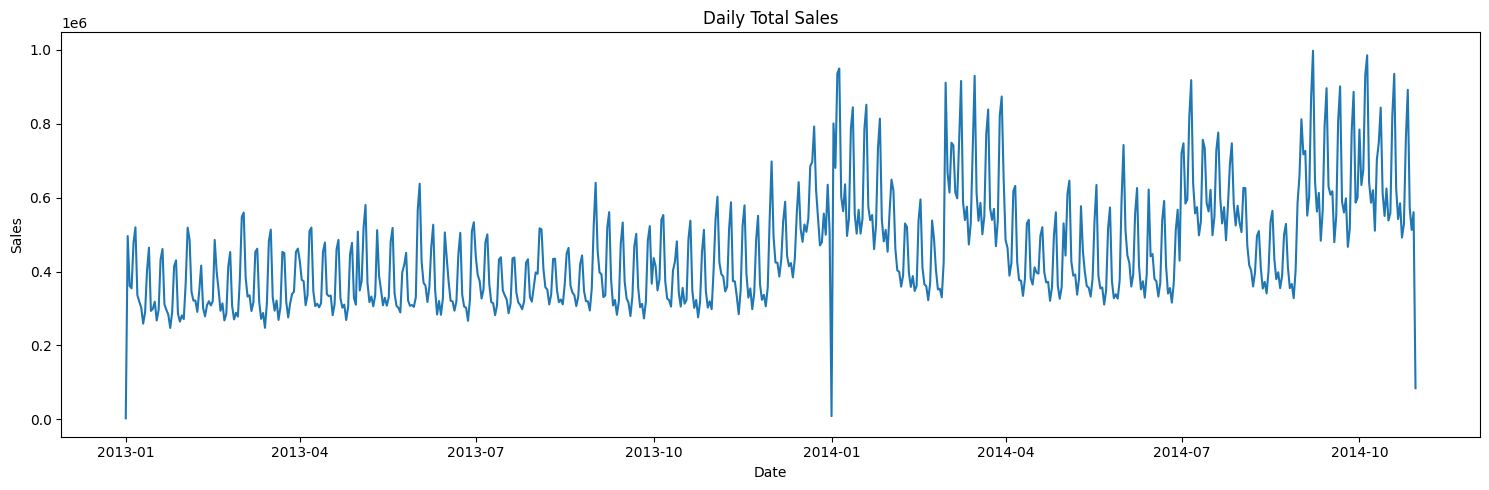

In [26]:
plt.figure(figsize=(15, 5))

plt.plot(ts)

plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

## Rolling Mean and Standard Deviation

Rolling statistics help examine how the central tendency and variability of the series change over time.

A stable rolling mean and standard deviation provide evidence that a series may be stationary, while substantial changes may indicate trend or other non-stationary behavior.

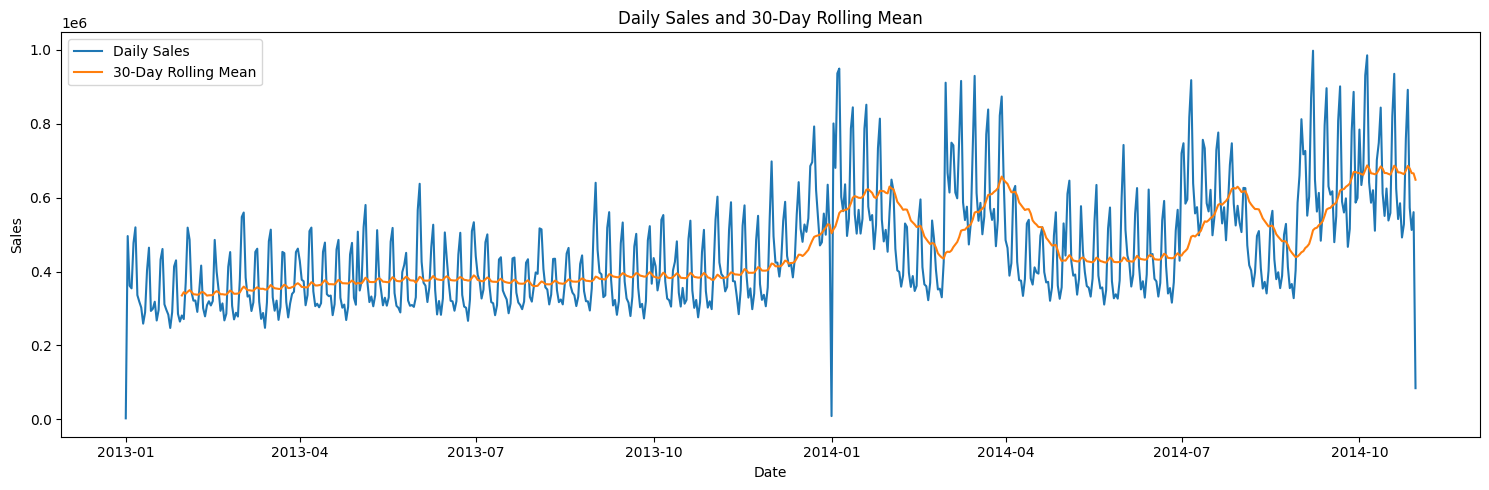

In [27]:
rolling_mean = ts.rolling(window=30).mean()
rolling_std = ts.rolling(window=30).std()

plt.figure(figsize=(15, 5))

plt.plot(ts, label="Daily Sales")
plt.plot(rolling_mean, label="30-Day Rolling Mean")

plt.title("Daily Sales and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

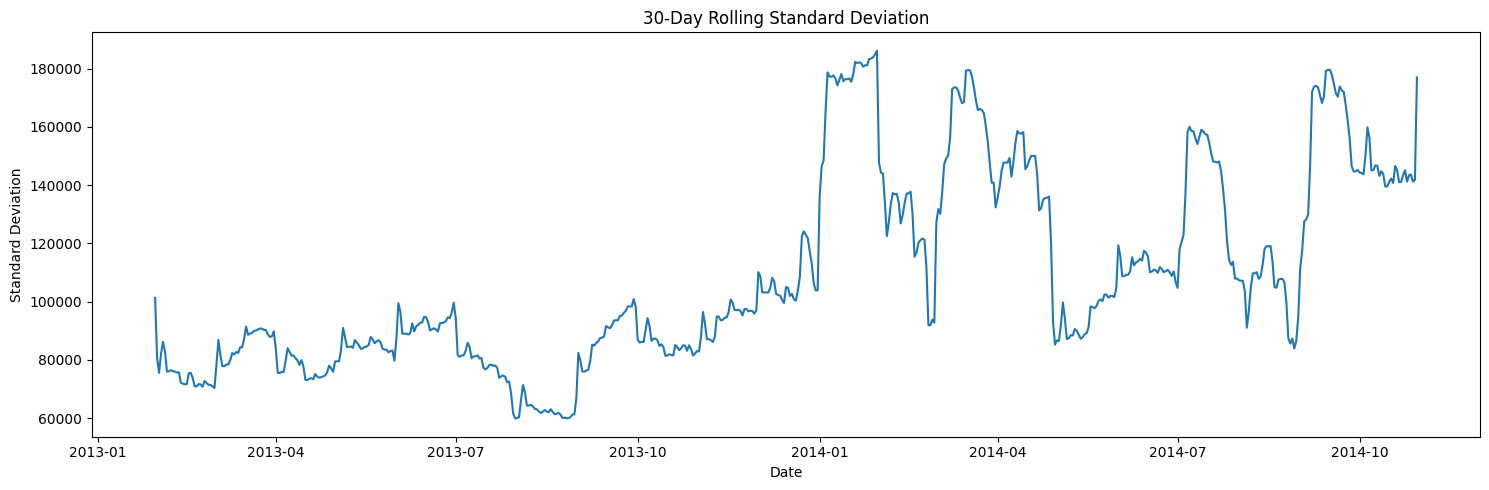

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(rolling_std)

plt.title("30-Day Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")

plt.tight_layout()
plt.show()

## Stationarity Test — Augmented Dickey-Fuller

The Augmented Dickey-Fuller (ADF) test is used to determine whether the daily sales series is stationary.

### Hypotheses

- H0: The time series is non-stationary.
- H1: The time series is stationary.

If the p-value is below 0.05, the null hypothesis is rejected and the series is considered stationary at the 5% significance level.

In [29]:
adf_result = adfuller(ts.dropna())

adf_statistic = adf_result[0]
p_value = adf_result[1]

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: The series is stationary.")
else:
    print("Conclusion: The series is non-stationary.")

ADF Statistic: -2.8074517392513862
p-value: 0.05721719878665042
Conclusion: The series is non-stationary.


## Time Series Decomposition

Time series decomposition separates the observed sales series into:

- Trend
- Seasonal component
- Residual component

A weekly seasonal period of 7 days is used initially because grocery purchasing behavior can contain weekly patterns.

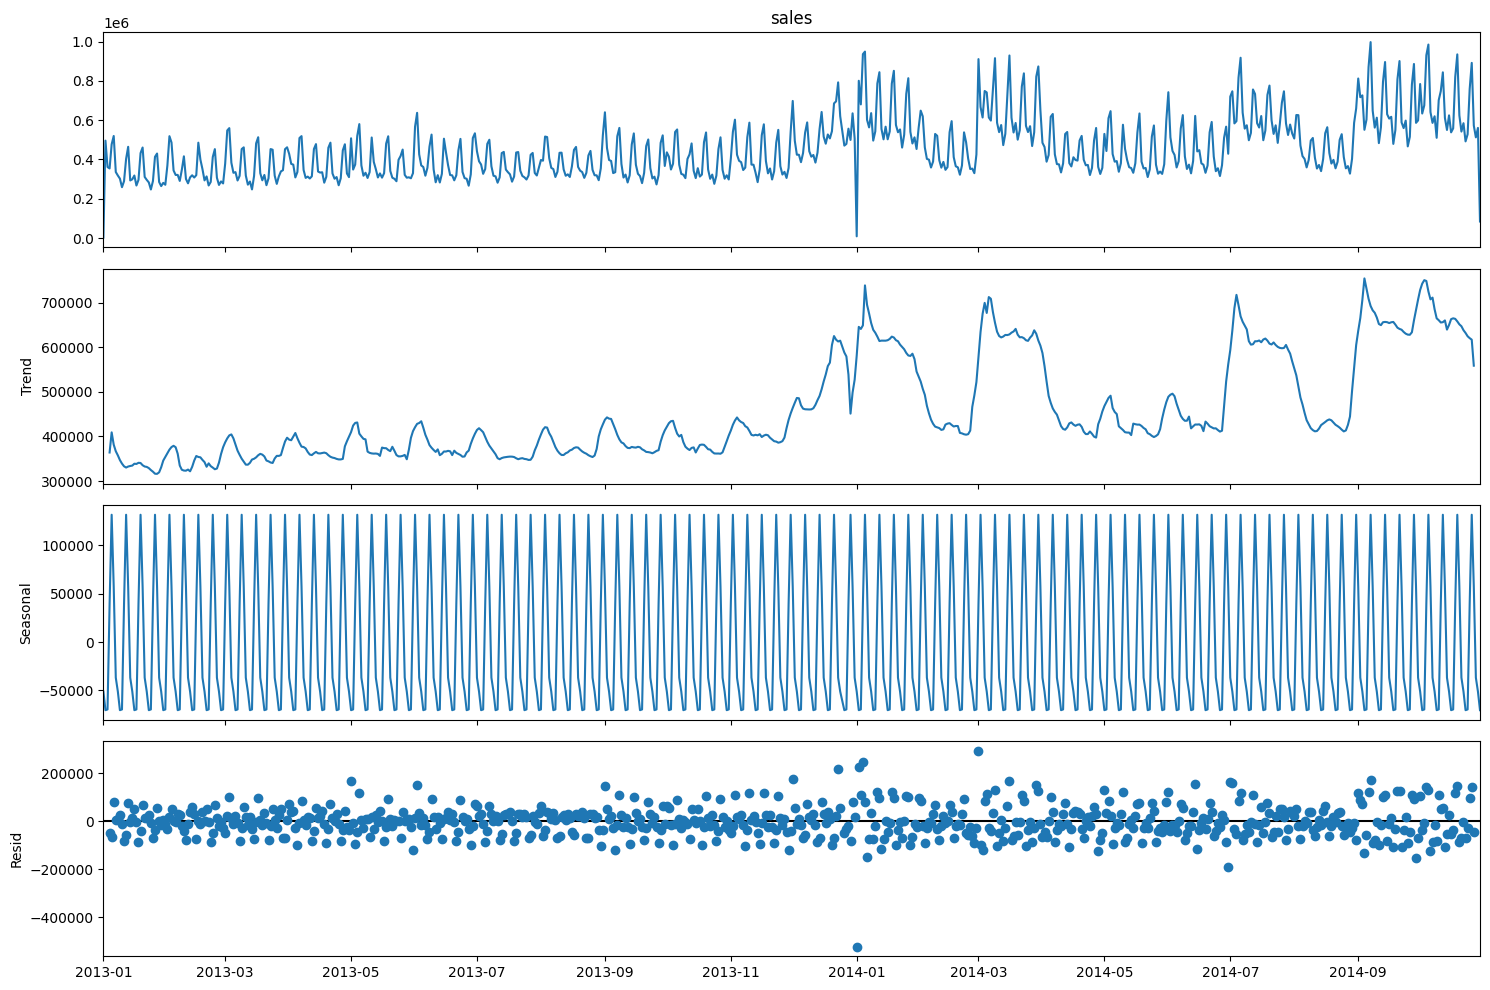

In [30]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

## Time-Based Train/Test Split

The most recent 16 days are reserved as the test set because the business requires a 16-day forecast horizon.

The split is performed chronologically rather than randomly. This ensures that the models are trained only on historical observations and evaluated on future observations.

In [39]:
forecast_horizon = 16

train = ts.iloc[:-forecast_horizon].copy()
test = ts.iloc[-forecast_horizon:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 651
Testing observations: 16

Training period:
2013-01-01 00:00:00 to 2014-10-14 00:00:00

Testing period:
2014-10-15 00:00:00 to 2014-10-30 00:00:00


## Baseline Forecast

A simple persistence baseline is used as a reference model.

The baseline assumes that future sales will remain equal to the most recently observed sales value.

More advanced forecasting models should ideally improve upon this baseline.

In [32]:
last_value = train.iloc[-1]

baseline_predictions = np.repeat(
    last_value,
    len(test)
)

baseline_mae = mean_absolute_error(
    test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test,
        baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 127092.75688968752
Baseline RMSE: 196385.41038078157


## 19. ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a classical time series forecasting model.

It consists of three components:

- AR (p): Uses previous observations to model the current value.
- I (d): Applies differencing to make a non-stationary series more stationary.
- MA (q): Uses previous forecast errors.

The ADF test showed that the sales series is non-stationary because the p-value was greater than 0.05. Therefore, first-order differencing is used by setting d = 1.

A simple ARIMA(1,1,1) model is used as a reproducible baseline forecasting model.

In [41]:
# Make sure the training index is a proper DatetimeIndex
train_arima = train.copy()
train_arima.index = pd.DatetimeIndex(train_arima.index)

# Make sure the data is sorted chronologically
train_arima = train_arima.sort_index()

# ARIMA model
arima_order = (1, 1, 1)

arima_model = ARIMA(
    train_arima,
    order=arima_order
)

arima_fit = arima_model.fit()

print("ARIMA model trained successfully!")
print("ARIMA order:", arima_order)

ARIMA model trained successfully!
ARIMA order: (1, 1, 1)


## 20. ARIMA 16-Day Forecast

The trained ARIMA model is used to forecast the next 16 days.

The forecast period corresponds to the same 16-day test set used for evaluating the baseline model.

In [44]:
# Create a clean numeric-index series for ARIMA
arima_series = pd.Series(
    train.values,
    index=np.arange(len(train)),
    dtype="float64"
)

print("ARIMA training observations:", len(arima_series))
print("Index type:", type(arima_series.index))

ARIMA training observations: 651
Index type: <class 'pandas.core.indexes.base.Index'>


In [45]:
# Fit ARIMA using a clean numeric index
arima_order = (1, 1, 1)

arima_model = ARIMA(
    arima_series,
    order=arima_order
)

arima_fit = arima_model.fit()

print("ARIMA model trained successfully!")
print("ARIMA order:", arima_order)

ARIMA model trained successfully!
ARIMA order: (1, 1, 1)


In [46]:
# Generate 16 future predictions
start = len(arima_series)
end = len(arima_series) + forecast_horizon - 1

arima_result = arima_fit.get_prediction(
    start=start,
    end=end
)

arima_forecast_values = np.asarray(
    arima_result.predicted_mean
)

print("Number of forecast values:", len(arima_forecast_values))
print("ARIMA forecast generated successfully!")

Number of forecast values: 16
ARIMA forecast generated successfully!


In [47]:
arima_predictions = pd.Series(
    arima_forecast_values,
    index=test.index
)

print("ARIMA predictions:")
display(arima_predictions)

ARIMA predictions:


,0
date,
2014-10-15,600768.020837
2014-10-16,626403.693419
2014-10-17,639500.705004
2014-10-18,646191.838692
2014-10-19,649610.272718
2014-10-20,651356.716853
2014-10-21,652248.957889
2014-10-22,652704.795011
2014-10-23,652937.677687


In [48]:
arima_mae = mean_absolute_error(
    test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_predictions
    )
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 148154.13142327167
ARIMA RMSE: 195676.8073526513


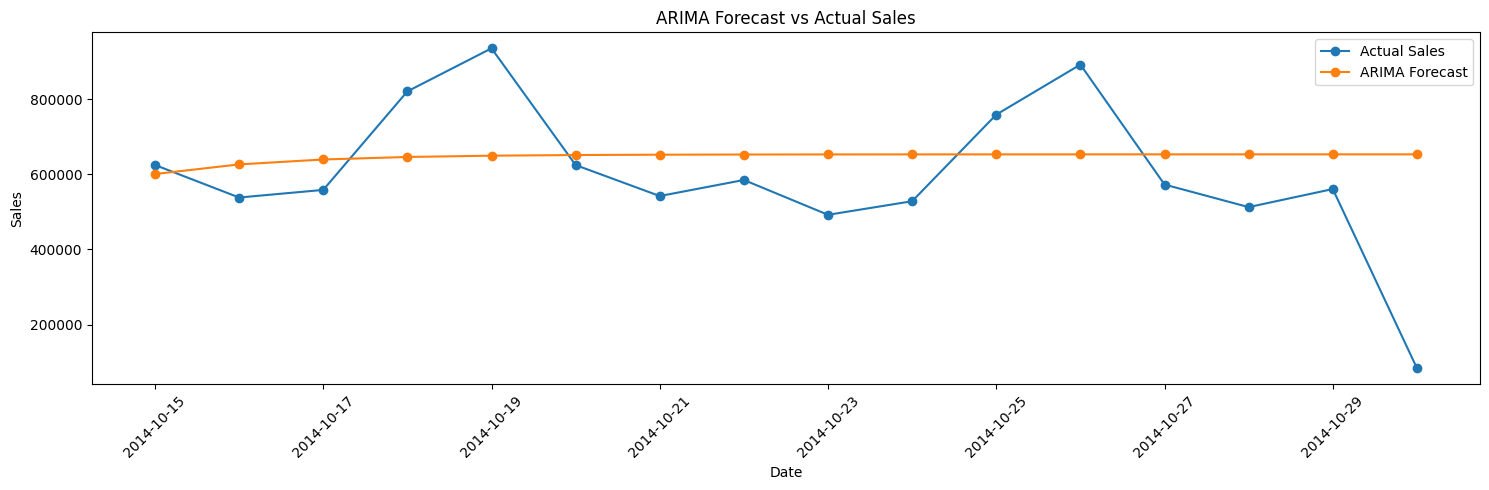

In [49]:
plt.figure(figsize=(15, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    arima_predictions.index,
    arima_predictions.values,
    label="ARIMA Forecast",
    marker="o"
)

plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 23. Prophet Forecasting

Prophet is a time series forecasting framework designed to model trend and seasonality.

It is useful for business forecasting because it can capture recurring patterns such as weekly and yearly seasonality.

Prophet requires two columns:

- `ds`: date
- `y`: target value

The model is trained only on the training data to prevent data leakage.

In [50]:
from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


In [51]:
!pip install prophet -q

## 24. Prepare Data for Prophet

The training time series is converted into the format required by Prophet.

Only the training observations are used so that the test period remains completely unseen during model training.

In [52]:
# Convert training data into Prophet format
prophet_train = train.reset_index()

# Rename columns for Prophet
prophet_train.columns = ["ds", "y"]

# Ensure date column has datetime format
prophet_train["ds"] = pd.to_datetime(
    prophet_train["ds"]
)

print("Prophet training data prepared successfully!")
print("Shape:", prophet_train.shape)

display(prophet_train.head())

Prophet training data prepared successfully!
Shape: (651, 2)


,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


## 25. Train Prophet Model

The Prophet model is trained using the historical training data.

Weekly seasonality is enabled to capture repeating weekly sales patterns, while yearly seasonality is enabled to capture longer-term seasonal behavior.

In [53]:
prophet_model = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully!")

Prophet model trained successfully!


## 26. Prophet 16-Day Forecast

The trained Prophet model is used to forecast the same 16-day test period used for the other forecasting models.

The test dates are supplied to the model without providing their actual sales values.

In [54]:
# Create future dates using the test period
prophet_future = pd.DataFrame({
    "ds": pd.to_datetime(test.index)
})

# Generate predictions
prophet_forecast = prophet_model.predict(
    prophet_future
)

# Extract predicted sales
prophet_predictions = pd.Series(
    prophet_forecast["yhat"].values,
    index=test.index
)

print("Prophet forecast generated successfully!")
print("\nForecasted values:")

display(prophet_predictions)

Prophet forecast generated successfully!

Forecasted values:


,0
date,
2014-10-15,598256.767771
2014-10-16,555097.147006
2014-10-17,593736.602664
2014-10-18,751978.634924
2014-10-19,782291.795779
2014-10-20,621090.570273
2014-10-21,577777.110553
2014-10-22,592178.149971
2014-10-23,550015.494001


## 27. Prophet Model Evaluation

The Prophet forecast is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Lower values indicate better forecasting performance.

In [55]:
prophet_mae = mean_absolute_error(
    test,
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test,
        prophet_predictions
    )
)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 75804.78968158114
Prophet RMSE: 133041.5079387535


## 28. Prophet Forecast vs Actual Sales

The following plot compares the actual sales values with the Prophet forecast during the 16-day test period.

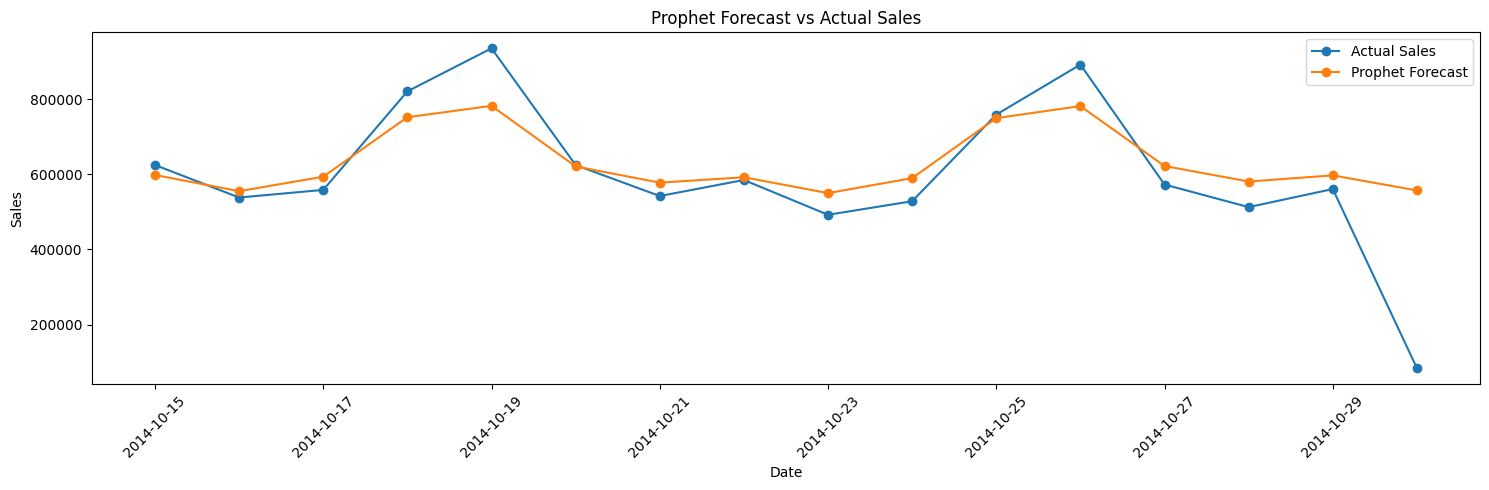

In [56]:
plt.figure(figsize=(15, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    prophet_predictions.index,
    prophet_predictions.values,
    label="Prophet Forecast",
    marker="o"
)

plt.title("Prophet Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 29. Machine Learning Approach: Lag Features

Time series forecasting can also be treated as a supervised machine learning problem.

Historical sales values are transformed into predictive features called lag features.

The following lag features are used:

- Lag 1: sales from the previous day
- Lag 7: sales from the previous week
- Lag 14: sales from two weeks earlier
- Lag 28: sales from four weeks earlier

Rolling averages are also created to capture recent sales trends.

All rolling features are calculated using previous observations only, which helps prevent future information from leaking into the model.

In [57]:
# Create ML dataset from the complete time series
ml_data = pd.DataFrame({
    "sales": ts
})

# Create lag features
for lag in [1, 7, 14, 28]:
    ml_data[f"lag_{lag}"] = ml_data["sales"].shift(lag)

# Create rolling mean features
ml_data["rolling_mean_7"] = (
    ml_data["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

ml_data["rolling_mean_14"] = (
    ml_data["sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

ml_data["rolling_mean_28"] = (
    ml_data["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

# Calendar features
ml_data["day_of_week"] = ml_data.index.dayofweek
ml_data["month"] = ml_data.index.month
ml_data["day"] = ml_data.index.day

# Remove rows containing NaN values caused by lagging
ml_data = ml_data.dropna()

print("ML dataset created successfully!")
print("Shape:", ml_data.shape)

display(ml_data.head())

ML dataset created successfully!
Shape: (639, 11)


,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,day_of_week,month,day
date,,,,,,,,,,,
2013-01-29,264488.818077,285460.169953,296214.728983,299129.549954,2511.618999,320916.224872,330877.422002,339672.163349,1,1,29
2013-01-30,281061.127052,264488.818077,283258.453032,318347.913946,496092.417944,316383.951885,328403.084010,349028.491888,2,1,30
2013-01-31,271254.217996,281061.127052,247245.690995,267498.515975,361461.231124,316070.048174,325739.742089,341348.802928,3,1,31
2013-02-01,369402.055266,271254.217996,290022.771930,296130.850028,354459.677093,319499.837745,326008.006519,338127.123887,4,2,1
2013-02-02,518887.462705,369402.055266,413799.767975,432459.852021,477350.121229,330839.735365,331241.664036,338660.780251,5,2,2


## 30. Time-Based Train/Test Split

The final 16 observations are reserved for testing.

A random train/test split is avoided because it could allow future observations to influence the training process.

A chronological split provides a more realistic representation of real-world forecasting.

In [58]:
# Split the supervised dataset chronologically
ml_train = ml_data.iloc[:-forecast_horizon].copy()
ml_test = ml_data.iloc[-forecast_horizon:].copy()

# Define feature columns
feature_cols = [
    col for col in ml_data.columns
    if col != "sales"
]

# Training data
X_train = ml_train[feature_cols]
y_train = ml_train["sales"]

# Testing data
X_test = ml_test[feature_cols]
y_test = ml_test["sales"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (623, 10)
X_test shape: (16, 10)
y_train shape: (623,)
y_test shape: (16,)


## 31. XGBoost Regression Model

XGBoost is a gradient boosting algorithm that can learn nonlinear relationships between historical sales patterns and future sales.

The model uses lagged sales, rolling averages, and calendar features as predictors.

In [59]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


## 32. XGBoost Model Evaluation

The trained XGBoost model is evaluated on the final 16 unseen observations.

MAE and RMSE are used to compare its forecasting performance with the baseline, ARIMA, and Prophet models.

In [60]:
xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 66813.6226971875
XGBoost RMSE: 129218.3226082016


## 33. XGBoost Forecast vs Actual Sales

The actual sales values are compared with the XGBoost predictions for the 16-day test period.

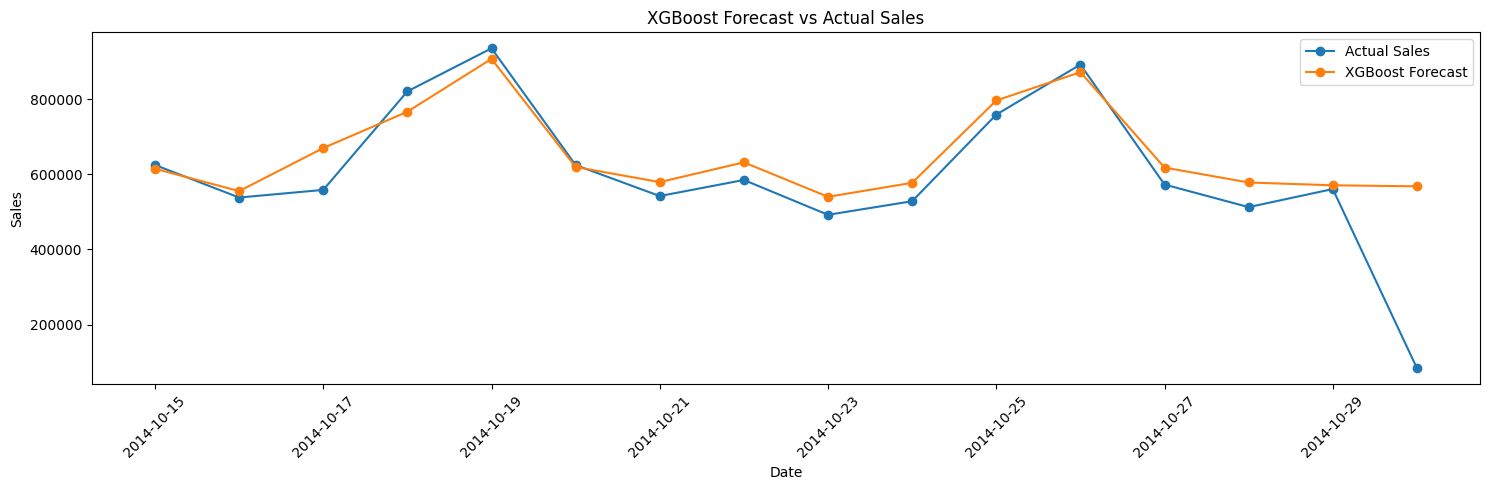

In [61]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost Forecast",
    marker="o"
)

plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 34. Time Series Cross-Validation

TimeSeriesSplit is used to evaluate the XGBoost approach while preserving chronological order.

In each fold, earlier observations are used for training and later observations are used for validation.

This prevents future observations from being used to predict the past and provides a more realistic estimate of model performance.

In [62]:
tscv = TimeSeriesSplit(n_splits=5)

fold_mae = []
fold_rmse = []

X_all = ml_data[feature_cols]
y_all = ml_data["sales"]

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_all),
    start=1
):

    X_fold_train = X_all.iloc[train_idx]
    X_fold_val = X_all.iloc[val_idx]

    y_fold_train = y_all.iloc[train_idx]
    y_fold_val = y_all.iloc[val_idx]

    fold_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_predictions = fold_model.predict(
        X_fold_val
    )

    fold_mae_value = mean_absolute_error(
        y_fold_val,
        fold_predictions
    )

    fold_rmse_value = np.sqrt(
        mean_squared_error(
            y_fold_val,
            fold_predictions
        )
    )

    fold_mae.append(fold_mae_value)
    fold_rmse.append(fold_rmse_value)

    print(
        f"Fold {fold}: "
        f"MAE = {fold_mae_value:.2f}, "
        f"RMSE = {fold_rmse_value:.2f}"
    )

print("\nAverage CV MAE:", np.mean(fold_mae))
print("Average CV RMSE:", np.mean(fold_rmse))

Fold 1: MAE = 22845.73, RMSE = 32108.28
Fold 2: MAE = 37806.26, RMSE = 54628.86
Fold 3: MAE = 122873.98, RMSE = 160264.08
Fold 4: MAE = 44664.30, RMSE = 64027.21
Fold 5: MAE = 55002.17, RMSE = 90200.57

Average CV MAE: 56638.48730462849
Average CV RMSE: 80245.79785533766


## 35. Forecasting Model Comparison

The baseline, ARIMA, Prophet, and XGBoost models are compared using MAE and RMSE.

Lower MAE and RMSE values indicate better forecasting performance.

The baseline provides a simple reference point, while ARIMA, Prophet, and XGBoost represent different forecasting approaches.

In [63]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "ARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        arima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        arima_rmse,
        prophet_rmse,
        xgb_rmse
    ]
})

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

display(results)

,Model,MAE,RMSE
0,XGBoost,66813.622697,129218.322608
1,Prophet,75804.789682,133041.507939
2,Baseline,127092.756890,196385.410381
3,ARIMA,148154.131423,195676.807353


## 36. Forecasting Model Comparison Visualization

The MAE values are visualized to make it easier to compare the forecasting performance of the tested models.

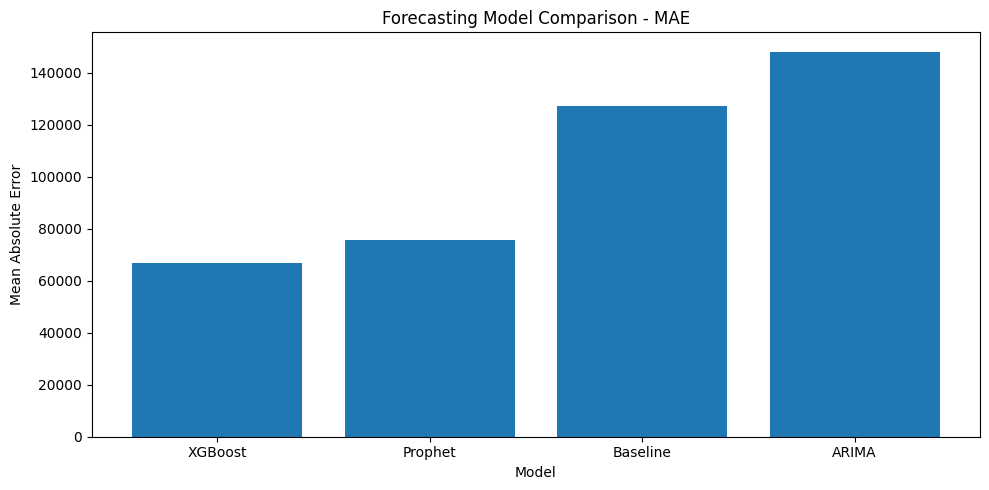

In [64]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("Forecasting Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()
plt.show()

## 37. Best Forecasting Model

The model with the lowest MAE is selected as the best-performing approach for the 16-day forecasting horizon.

MAE is used as the primary metric because it directly represents the average absolute forecasting error in sales units.

In [65]:
best_model_row = results.loc[
    results["MAE"].idxmin()
]

best_model_name = best_model_row["Model"]
best_mae = best_model_row["MAE"]
best_rmse = best_model_row["RMSE"]

print("Best Model:", best_model_name)
print("Best MAE:", best_mae)
print("Best RMSE:", best_rmse)

Best Model: XGBoost
Best MAE: 66813.6226971875
Best RMSE: 129218.3226082016


## 38. Final 16-Day Forecast

The selected best-performing model is used to represent the final 16-day forecast.

The forecast is compared with the actual values from the test period to assess how well the selected model follows real sales demand.

In [66]:
if best_model_name == "Baseline":

    final_predictions = pd.Series(
        baseline_predictions,
        index=test.index
    )

elif best_model_name == "ARIMA":

    final_predictions = arima_predictions

elif best_model_name == "Prophet":

    final_predictions = prophet_predictions

elif best_model_name == "XGBoost":

    final_predictions = pd.Series(
        xgb_predictions,
        index=y_test.index
    )

print("Final Model:", best_model_name)

display(
    pd.DataFrame({
        "Actual Sales": test.values,
        "Forecast": final_predictions.values
    }, index=test.index)
)

Final Model: XGBoost


,Actual Sales,Forecast
date,,
2014-10-15,624797.469491,614886.8750
2014-10-16,538252.607117,555328.0625
2014-10-17,558538.135999,669940.7500
2014-10-18,820840.970792,766698.3125
2014-10-19,935410.595877,907356.6250
2014-10-20,624629.990941,619476.6875
2014-10-21,542207.165266,579277.5000
2014-10-22,584926.355993,631938.2500
2014-10-23,492233.232200,540133.1250


## 39. Final Forecast Visualization

The final forecast is visualized alongside recent historical sales and the actual test-period observations.

This provides a practical view of the selected model's forecasting performance over the 16-day horizon.

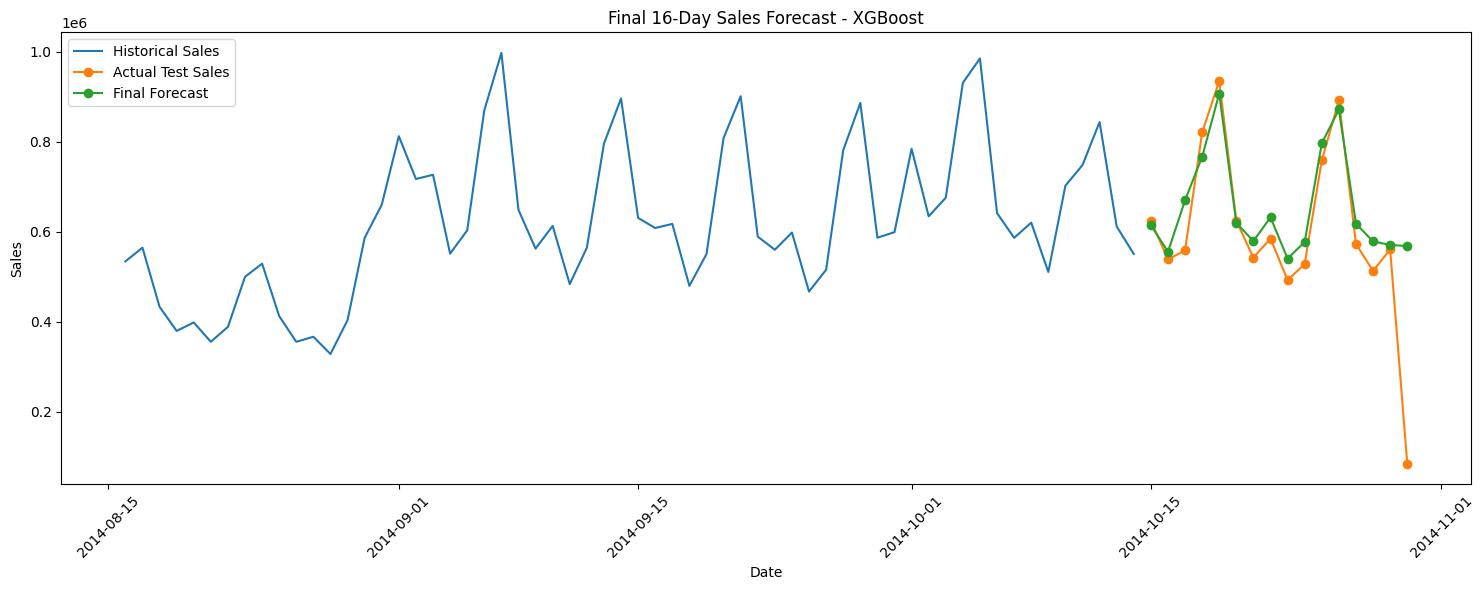

In [67]:
plt.figure(figsize=(15, 6))

plt.plot(
    train.index[-60:],
    train.iloc[-60:],
    label="Historical Sales"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Test Sales",
    marker="o"
)

plt.plot(
    final_predictions.index,
    final_predictions.values,
    label="Final Forecast",
    marker="o"
)

plt.title(
    f"Final 16-Day Sales Forecast - {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 40. Business Interpretation

The grocery chain requires reliable 16-day sales forecasts to support inventory ordering decisions across its stores.

Accurate forecasting can help the business:

- Reduce excess inventory and product spoilage.
- Reduce stockouts and potential lost sales.
- Improve purchasing decisions.
- Improve inventory allocation.
- Support better demand planning.

The model with the lowest forecasting error provides the strongest performance among the tested approaches.

Forecasts should be treated as decision-support information rather than exact guarantees of future demand.

## 41. Limitations

The forecasting approach has several limitations:

- Sales were aggregated across stores and product families, which can hide individual store-level patterns.
- Only a 16-day holdout period was used for final evaluation.
- External factors such as holidays, weather, and local events were not fully incorporated.
- Lag-based forecasting may accumulate errors over longer forecasting horizons.
- Model performance may change when future demand patterns differ from historical patterns.

## 42. Conclusion

This project implemented a complete time series forecasting workflow for grocery sales.

The dataset was cleaned and transformed into a daily sales time series. Exploratory analysis, rolling statistics, stationarity testing using the ADF test, and seasonal decomposition were performed.

Multiple forecasting approaches were implemented, including a simple baseline, ARIMA, Prophet, and XGBoost with lag-based features. TimeSeriesSplit was also used to evaluate the machine learning approach while preserving chronological order.

The models were compared using MAE and RMSE, and the model with the lowest MAE was selected as the final forecasting approach.

The overall workflow demonstrates how time series forecasting can support inventory planning and help reduce the business impact of overforecasting and underforecasting.